# MLiP Data Exploration

Exploratory Data Analysis der MLiP_data/al5083 Dataset

In [6]:
import json
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# Pfad zu den Daten
DATA_DIR = Path('C:/Users/domin/Documents/MLiP/Repository/MLiP_Project/MLiP_data/al5083')

print(f"Data directory: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}\n")

# Übersicht der Verzeichnisstruktur
print("=== Verzeichnisstruktur ===")
print(f"Train dir: {DATA_DIR / 'train'} - Exists: {(DATA_DIR / 'train').exists()}")
print(f"Test dir: {DATA_DIR / 'test'} - Exists: {(DATA_DIR / 'test').exists()}")


Data directory: C:\Users\domin\Documents\MLiP\Repository\MLiP_Project\MLiP_data\al5083
Exists: True

=== Verzeichnisstruktur ===
Train dir: C:\Users\domin\Documents\MLiP\Repository\MLiP_Project\MLiP_data\al5083\train - Exists: True
Test dir: C:\Users\domin\Documents\MLiP\Repository\MLiP_Project\MLiP_data\al5083\test - Exists: True


In [7]:
# Lade Train JSON
train_json_path = DATA_DIR / 'train' / 'train.json'
test_json_path = DATA_DIR / 'test' / 'test.json'

print("\n=== Train Dataset ===")
if train_json_path.exists():
    with open(train_json_path) as f:
        train_data = json.load(f)
    print(f"Anzahl Bilder (JSON): {len(train_data)}")
    
    # Zeige erste paar Einträge
    print("\nErste 3 Einträge:")
    for i, (img_name, label) in enumerate(list(train_data.items())[:3]):
        print(f"  {img_name}: {label}")
    
    # Label-Verteilung
    from collections import Counter
    label_counts = Counter(train_data.values())
    print(f"\nLabel-Verteilung: {dict(label_counts)}")
else:
    print(f"Train JSON nicht gefunden: {train_json_path}")

print("\n=== Test Dataset ===")
if test_json_path.exists():
    with open(test_json_path) as f:
        test_data = json.load(f)
    print(f"Anzahl Bilder (JSON): {len(test_data)}")
    
    # Zeige erste paar Einträge
    print("\nErste 3 Einträge:")
    for i, (img_name, label) in enumerate(list(test_data.items())[:3]):
        print(f"  {img_name}: {label}")
    
    # Label-Verteilung
    test_label_counts = Counter(test_data.values())
    print(f"\nLabel-Verteilung: {dict(test_label_counts)}")
else:
    print(f"Test JSON nicht gefunden: {test_json_path}")



=== Train Dataset ===
Anzahl Bilder (JSON): 26666

Erste 3 Einträge:
  170906-113317-Al 2mm-part3/frame_00647.png: 1
  170906-113317-Al 2mm-part3/frame_00672.png: 1
  170906-113317-Al 2mm-part3/frame_00677.png: 1

Label-Verteilung: {1: 1783, 2: 6325, 4: 2953, 0: 8758, 5: 2819, 3: 4028}

=== Test Dataset ===
Anzahl Bilder (JSON): 6588

Erste 3 Einträge:
  170906-143512-Al 2mm-part2/frame_01945.png: 1
  170906-143512-Al 2mm-part2/frame_01888.png: 1
  170906-143512-Al 2mm-part2/frame_01759.png: 1

Label-Verteilung: {1: 351, 2: 2078, 4: 729, 0: 2189, 5: 234, 3: 1007}


In [8]:
# Zähle tatsächliche Bilder in den Verzeichnissen
print("\n=== Anzahl Bilder im Dateisystem ===")

train_dir = DATA_DIR / 'train'
test_dir = DATA_DIR / 'test'

# Zähle Bilder im Train-Verzeichnis (ignoriere train.json)
train_images = []
for root, dirs, files in os.walk(train_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            train_images.append(os.path.join(root, file))

print(f"Train Bilder gefunden: {len(train_images)}")

# Zähle Bilder im Test-Verzeichnis (ignoriere test.json)
test_images = []
for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            test_images.append(os.path.join(root, file))

print(f"Test Bilder gefunden: {len(test_images)}")

# Vergleich
print(f"\n=== Vergleich JSON vs Dateisystem ===")
print(f"Train: JSON={len(train_data)}, Dateisystem={len(train_images)}")
print(f"Test: JSON={len(test_data)}, Dateisystem={len(test_images)}")



=== Anzahl Bilder im Dateisystem ===
Train Bilder gefunden: 26666
Test Bilder gefunden: 6588

=== Vergleich JSON vs Dateisystem ===
Train: JSON=26666, Dateisystem=26666
Test: JSON=6588, Dateisystem=6588



=== Beispielbilder ===
  170913-152931-Al 2mm-part1/frame_00494.png (Label: 0) - Size: (800, 974)
  170906-113317-Al 2mm-part3/frame_00647.png (Label: 1) - Size: (800, 974)
  170904-141730-Al 2mm-part2/frame_00145.png (Label: 2) - Size: (800, 974)
  170906-150010-Al 2mm/frame_00494.png (Label: 3) - Size: (800, 974)
  170904-145718-Al 2mm-part2/frame_00647.png (Label: 4) - Size: (800, 974)
  170905-110711-Al 2mm-part1/frame_00280.png (Label: 5) - Size: (800, 974)


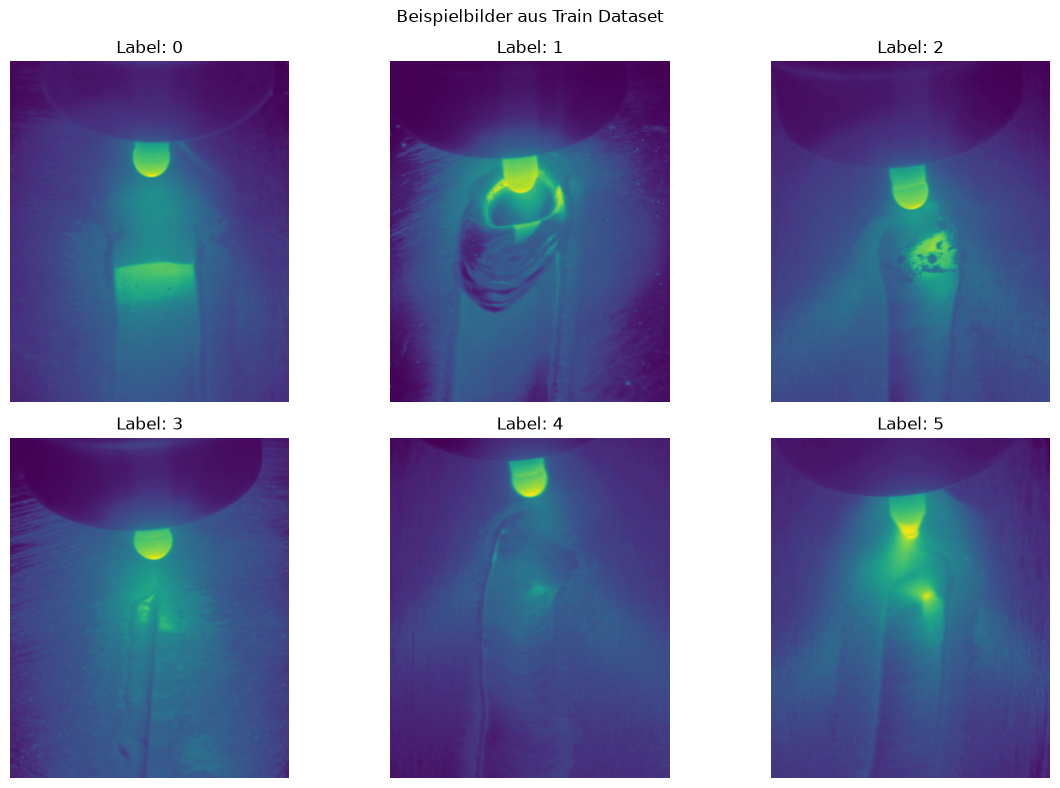

In [9]:
# Visualisiere Sample Bilder aus verschiedenen Labels
print("\n=== Beispielbilder ===")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Beispielbilder aus Train Dataset')

# Gruppiere Bilder nach Labels
from collections import defaultdict
images_by_label = defaultdict(list)

for img_name, label in train_data.items():
    images_by_label[label].append(img_name)

# Zeige 1 Bild pro Label
plot_idx = 0
for label in sorted(images_by_label.keys())[:6]:
    img_name = images_by_label[label][0]
    img_path = train_dir / img_name
    
    if img_path.exists():
        img = Image.open(img_path)
        row = plot_idx // 3
        col = plot_idx % 3
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"Label: {label}")
        axes[row, col].axis('off')
        plot_idx += 1
        
        print(f"  {img_name} (Label: {label}) - Size: {img.size}")
    else:
        print(f"  {img_path} nicht gefunden!")

# Verstecke leere Subplots
for idx in range(plot_idx, 6):
    row = idx // 3
    col = idx % 3
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


In [10]:
# Detaillierte Statistiken
print("\n=== Detaillierte Statistiken ===")

# Bildgrößen analysieren
print("\nTrain - Bildgrößen (Sample von 10):")
sizes = []
for i, img_name in enumerate(list(train_data.keys())[:10]):
    img_path = train_dir / img_name
    if img_path.exists():
        img = Image.open(img_path)
        sizes.append(img.size)
        print(f"  {img_name}: {img.size}")

if sizes:
    print(f"\nDurchschnittliche Größe: {np.mean(sizes, axis=0)}")

# Label-Statistiken
print("\n=== Label Statistiken ===")
print("Train Labels:")
for label, count in sorted(label_counts.items()):
    print(f"  Label {label}: {count} Bilder")

print("\nTest Labels:")
for label, count in sorted(test_label_counts.items()):
    print(f"  Label {label}: {count} Bilder")

# Gesamtübersicht
print("\n=== Zusammenfassung ===")
print(f"Gesamt Train Bilder: {len(train_data)}")
print(f"Gesamt Test Bilder: {len(test_data)}")
print(f"Gesamtzahl Labels: {len(label_counts)}")
print(f"Train/Test Verhältnis: {len(train_data)}/{len(test_data)}")



=== Detaillierte Statistiken ===

Train - Bildgrößen (Sample von 10):
  170906-113317-Al 2mm-part3/frame_00647.png: (800, 974)
  170906-113317-Al 2mm-part3/frame_00672.png: (800, 974)
  170906-113317-Al 2mm-part3/frame_00677.png: (800, 974)
  170906-113317-Al 2mm-part3/frame_00646.png: (800, 974)
  170906-113317-Al 2mm-part3/frame_00691.png: (800, 974)
  170906-113317-Al 2mm-part3/frame_00684.png: (800, 974)
  170906-113317-Al 2mm-part3/frame_00665.png: (800, 974)
  170906-113317-Al 2mm-part3/frame_00668.png: (800, 974)
  170906-113317-Al 2mm-part3/frame_00651.png: (800, 974)
  170906-113317-Al 2mm-part3/frame_00655.png: (800, 974)

Durchschnittliche Größe: [800. 974.]

=== Label Statistiken ===
Train Labels:
  Label 0: 8758 Bilder
  Label 1: 1783 Bilder
  Label 2: 6325 Bilder
  Label 3: 4028 Bilder
  Label 4: 2953 Bilder
  Label 5: 2819 Bilder

Test Labels:
  Label 0: 2189 Bilder
  Label 1: 351 Bilder
  Label 2: 2078 Bilder
  Label 3: 1007 Bilder
  Label 4: 729 Bilder
  Label 5: 234 